<a href="https://colab.research.google.com/github/DananjayaChathuranga/ML_Group6_CW1/blob/main/Group%2006%20Completed_CI7521_CW1_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
jupyter nbcovert --to docx Copy of CI7521_CW1_2026.ipynb

SyntaxError: invalid syntax (3908335645.py, line 1)

# Coursework 1 Group 06

Group number: 6

Student names and k-numbers:
1. K2635998 - Dananjaya Chathuranga
2. K2635984 - Nethra Herath
3. K2635944 - Sadeep Sachintha

# Load modules (code)

In [ ]:
# add code for loading modules - Done by Dananjaya K2635998
from sklearn.datasets import fetch_openml
dataset = fetch_openml(data_id=4538, as_frame=False)

print("Keys in dataset:", dataset.keys())

Keys in dataset: dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


# Load data (code)

In [ ]:
# add code for loading data - Done by Dananjaya K2635998
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the GesturePhoaseSEgmentationprocessed dataset (ID: 4538) - Done by Dananjaya K2635998
dataset = fetch_openml(data_id=4538, as_frame=False)

X = dataset.data
# Use LabelEncoder to convert categorical target labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(dataset.target)

print("Shape X", X.shape)
print("Labels shape", y.shape)
print("Original target classes -", label_encoder.classes_)
print("encoded lables -", np.unique(y))
print("Encoded target labels (first 5):\n - ", y[:5])


#train/test split (70%/30%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print("Shape X train raw -", X_train_raw.shape)
print("Shape X test raw -", X_test_raw.shape)


#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

#Dimenstionality Reduction (PCA) - using 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original dimensions -", X.shape[1])
print("Reduced dimensions (PCA) - ", X_train_pca.shape[1])

#_____________________________________________________________________________________END_Dananjaya______________________________________________________

Shape X (9873, 32)
Labels shape (9873,)
Original target classes - ['D' 'H' 'P' 'R' 'S']
encoded lables - [0 1 2 3 4]
Encoded target labels (first 5):
 -  [0 0 0 0 0]
Shape X train raw - (6911, 32)
Shape X test raw - (2962, 32)
Original dimensions - 32
Reduced dimensions (PCA) -  20


# Classification

## Classification methods used

This notebook applies eight classical machine learning classification methods:

1.   Logistic Regression - K2635998
2.   Support Vector Machine - SVM - K2635998
3.   Random Forest - K2635984
4.   K-Nearest Neighbors - K2635984
5.   Decision Tree - K2635944
6.   AdaBoost - K2635944
7.   Gaussian Naive Bayes - K2635944
8.   Multi-Layer Perceptron - K2635944

All methods undergo hyperparameter tuning using GridSearchCV where applicable.
Dimensionality reduction variants may be treated as additional methods in extended work.



## Training (code)

In [ ]:
#add code for training
#___________________________________________________________________START_Dananjaya_______________________________________________
# Done by Dananjaya from this point

#logistic regression (no PCA)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


log_reg_params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"],
    "max_iter": [300]
}

log_reg_grid = GridSearchCV(
    LogisticRegression(),
    log_reg_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)
log_reg_grid.fit(X_train_scaled, y_train)
log_reg_best = log_reg_grid.best_estimator_

print("Best parameters for Logistic Regression with no PCA -", log_reg_grid.best_params_)


#logistic regression (with PCA)
log_reg_pca = GridSearchCV (
    LogisticRegression(),
    log_reg_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

log_reg_pca.fit(X_train_pca, y_train)
log_reg_best_pca = log_reg_pca.best_estimator_

print("Best parameters for Logistic Regression with PCA -", log_reg_pca.best_params_)


#Support Vector Machine (No PCA)
from sklearn.svm import SVC

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    svm_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_

print("Best parameters for SVM with no PCA -", svm_grid.best_params_)


#Support Vector Machine (with PCA)
svm_grid_pca = GridSearchCV(
    SVC(probability=True),
    svm_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

svm_grid_pca.fit(X_train_pca, y_train)
svm_best_pca = svm_grid_pca.best_estimator_

print("Best parameters for SVM with PCA -", svm_grid_pca.best_params_)

#_______________________________________________________________________End_Dananjaya____________________________________________________________________

Best parameters for Logistic Regression with no PCA - {'C': 10, 'max_iter': 300, 'penalty': 'l2', 'solver': 'liblinear'}
Best parameters for Logistic Regression with PCA - {'C': 1, 'max_iter': 300, 'penalty': 'l2', 'solver': 'liblinear'}
Best parameters for SVM with no PCA - {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best parameters for SVM with PCA - {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [ ]:
# K2635984 - Nethra Herath
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             roc_curve, confusion_matrix, classification_report)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# Method 1: Random Forest with Hyperparameter Tuning
print("\nMethod 1: Random Forest Classifier")
print("-"*30)
# Define hyperparameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create Random Forest classifier
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Perform grid search with cross-validation
rf_grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='balanced_accuracy',
                              n_jobs=-1, verbose=1)
rf_grid_search.fit(X_train_scaled, y_train)

# Best model
best_rf = rf_grid_search.best_estimator_
print(f"Best parameters: {rf_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_grid_search.best_score_:.4f}")

# Method 2: K-Nearest Neighbors with Hyperparameter Tuning
print("\nMethod 2: K-Nearest Neighbors Classifier")
print("-"*30)
# Define hyperparameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # p=1 for manhattan, p=2 for euclidean
}

# Create KNN classifier
knn = KNeighborsClassifier()

# Perform grid search with cross-validation
knn_grid_search = GridSearchCV(knn, knn_param_grid, cv=5, scoring='balanced_accuracy',
                               n_jobs=-1, verbose=1)
knn_grid_search.fit(X_train_scaled, y_train)

# Best model
best_knn = knn_grid_search.best_estimator_
print(f"Best parameters: {knn_grid_search.best_params_}")
print(f"Best cross-validation score: {knn_grid_search.best_score_:.4f}")

# Additional methods (if needed, add more here)
# Method 3: Random Forest with PCA dimensionality reduction
from sklearn.decomposition import PCA

print("\nMethod 3: Random Forest with PCA Dimensionality Reduction")
print("-"*30)

# Apply PCA
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"PCA features (95% variance): {X_train_pca.shape[1]}")

# Train Random Forest on PCA-transformed data
rf_pca = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20)
rf_pca.fit(X_train_pca, y_train)

# Method 4: KNN with PCA
print("\nMethod 4: KNN with PCA Dimensionality Reduction")
print("-"*30)

knn_pca = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='minkowski', p=2)
knn_pca.fit(X_train_pca, y_train)

# Method 5: Weighted Random Forest

print("Weighted Random Forest (Balanced Class Weights)")
print("-"*40)

# Calculate class weights for imbalanced datasets
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

rf_weighted = RandomForestClassifier(
    class_weight=class_weight_dict,
    random_state=42,
    n_jobs=-1
)

rf_weighted_grid_search = GridSearchCV(
    rf_weighted,
    rf_param_grid,
    cv=5,
    scoring='balanced_accuracy',
    n_jobs=-1,
    verbose=1
)
rf_weighted_grid_search.fit(X_train_scaled, y_train)

best_rf_weighted = rf_weighted_grid_search.best_estimator_
print(f"Best parameters: {rf_weighted_grid_search.best_params_}")
print(f"Best cross-validation score: {rf_weighted_grid_search.best_score_:.4f}")


Method 1: Random Forest Classifier
------------------------------
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validation score: 0.5643

Method 2: K-Nearest Neighbors Classifier
------------------------------
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best cross-validation score: 0.5811

Method 3: Random Forest with PCA Dimensionality Reduction
------------------------------
Original features: 32
PCA features (95% variance): 20

Method 4: KNN with PCA Dimensionality Reduction
------------------------------
Weighted Random Forest (Balanced Class Weights)
----------------------------------------
Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estima

In [ ]:
#K2635944 - Sadeep
# Decision Tree (No PCA)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)
dt_best = dt_grid.best_estimator_

print("Best parameters for Decision Tree (no PCA):", dt_grid.best_params_)

# Decision Tree (With PCA)
dt_pca_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dt_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

dt_pca_grid.fit(X_train_pca, y_train)
dt_best_pca = dt_pca_grid.best_estimator_

print("Best parameters for Decision Tree (with PCA):", dt_pca_grid.best_params_)

# AdaBoost (No PCA)
from sklearn.ensemble import AdaBoostClassifier

ada_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.1, 0.5, 1.0]
}

ada_grid = GridSearchCV(
    AdaBoostClassifier(),
    ada_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

ada_grid.fit(X_train_scaled, y_train)
ada_best = ada_grid.best_estimator_

print("Best parameters for AdaBoost (no PCA):", ada_grid.best_params_)

# AdaBoost (With PCA)
ada_pca_grid = GridSearchCV(
    AdaBoostClassifier(),
    ada_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

ada_pca_grid.fit(X_train_pca, y_train)
ada_best_pca = ada_pca_grid.best_estimator_

print("Best parameters for AdaBoost (with PCA):", ada_pca_grid.best_params_)

# Gaussian Naive Bayes (No PCA)
from sklearn.naive_bayes import GaussianNB

nb_params = {
    "var_smoothing": [1e-09, 1e-08, 1e-07, 1e-06]
}

nb_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

nb_grid.fit(X_train_scaled, y_train)
nb_best = nb_grid.best_estimator_

print("Best parameters for Gaussian NB (no PCA):", nb_grid.best_params_)

# Gaussian Naive Bayes (With PCA)
nb_pca_grid = GridSearchCV(
    GaussianNB(),
    nb_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

nb_pca_grid.fit(X_train_pca, y_train)
nb_best_pca = nb_pca_grid.best_estimator_

print("Best parameters for Gaussian NB (with PCA):", nb_pca_grid.best_params_)

# MLP (No PCA)
from sklearn.neural_network import MLPClassifier

mlp_params = {
    "hidden_layer_sizes": [(50,), (100,), (150,)],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.01]
}

mlp_grid = GridSearchCV(
    MLPClassifier(max_iter=500),
    mlp_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

mlp_grid.fit(X_train_scaled, y_train)
mlp_best = mlp_grid.best_estimator_

print("Best parameters for MLP (no PCA):", mlp_grid.best_params_)

# MLP (With PCA)
mlp_pca_grid = GridSearchCV(
    MLPClassifier(max_iter=500),
    mlp_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

mlp_pca_grid.fit(X_train_pca, y_train)
mlp_best_pca = mlp_pca_grid.best_estimator_

print("Best parameters for MLP (with PCA):", mlp_pca_grid.best_params_)


Best parameters for Decision Tree (no PCA): {'criterion': 'entropy', 'max_depth': 30, 'min_samples_split': 2}
Best parameters for Decision Tree (with PCA): {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2}
Best parameters for AdaBoost (no PCA): {'learning_rate': 1.0, 'n_estimators': 150}
Best parameters for AdaBoost (with PCA): {'learning_rate': 1.0, 'n_estimators': 150}
Best parameters for Gaussian NB (no PCA): {'var_smoothing': 1e-09}
Best parameters for Gaussian NB (with PCA): {'var_smoothing': 1e-09}
Best parameters for MLP (no PCA): {'alpha': 0.0001, 'hidden_layer_sizes': (150,), 'learning_rate_init': 0.01}
Best parameters for MLP (with PCA): {'alpha': 0.001, 'hidden_layer_sizes': (150,), 'learning_rate_init': 0.01}


## Evaluation (code)

{'LR': {'Balanced Accuracy': np.float64(0.3518490457556573), 'Macro AUC': np.float64(0.7569180219220417), 'Micro AUC': np.float64(0.7839248760236004)}, 'LR_PCA': {'Balanced Accuracy': np.float64(0.34625362259623593), 'Macro AUC': np.float64(0.7456269852619826), 'Micro AUC': np.float64(0.7785956974250932)}, 'SVM': {'Balanced Accuracy': np.float64(0.4692792914940159), 'Macro AUC': np.float64(0.8087817110859378), 'Micro AUC': np.float64(0.8335299968860577)}, 'SVM_PCA': {'Balanced Accuracy': np.float64(0.46439195400673167), 'Macro AUC': np.float64(0.800392361617153), 'Micro AUC': np.float64(0.8289829797739634)}}


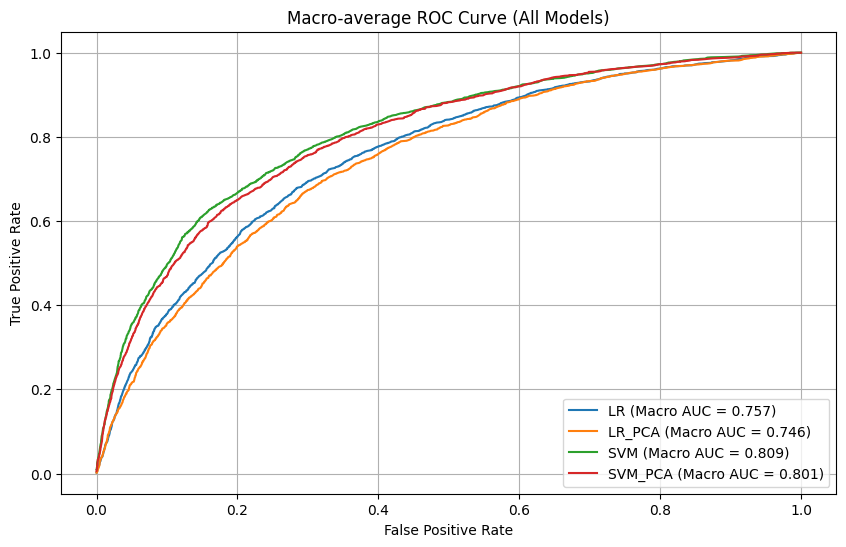

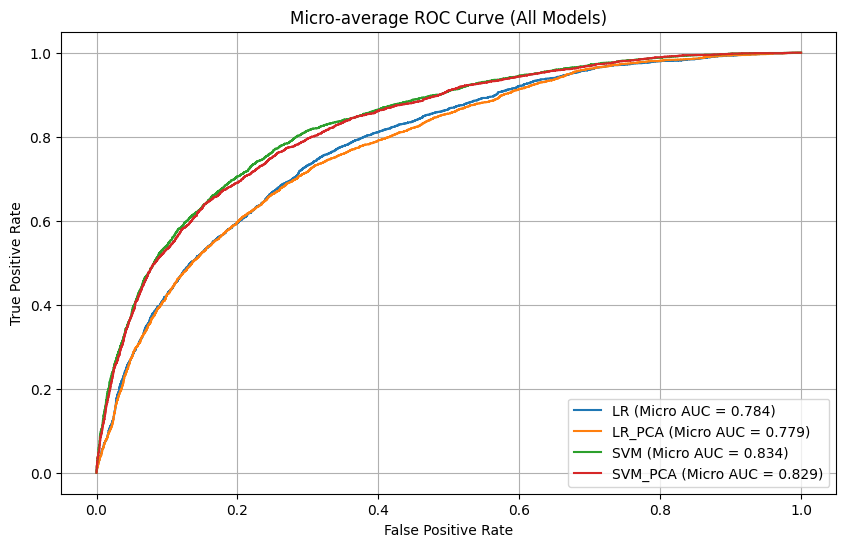

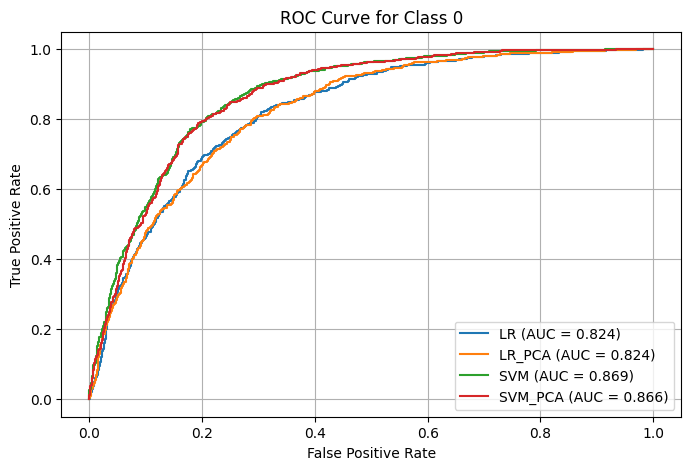

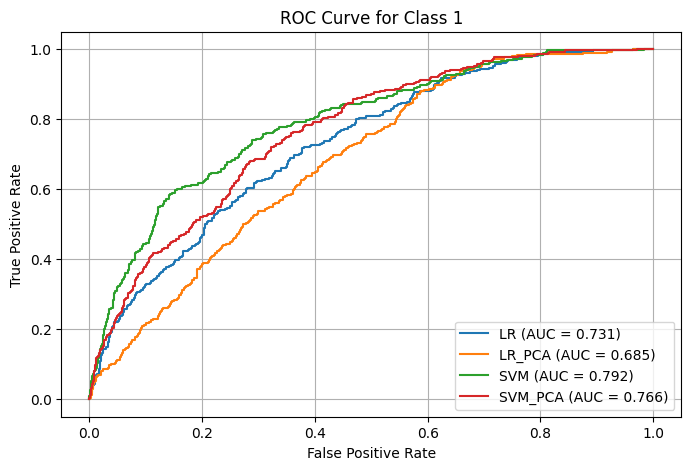

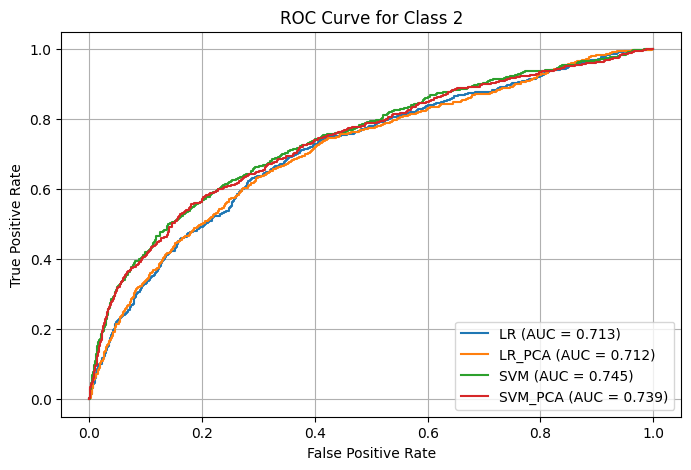

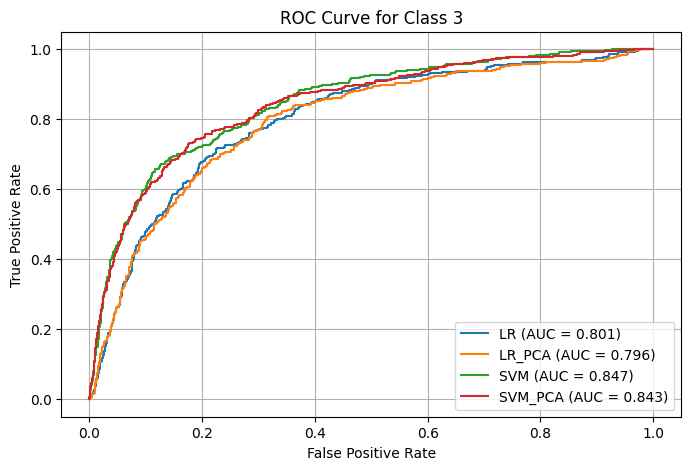

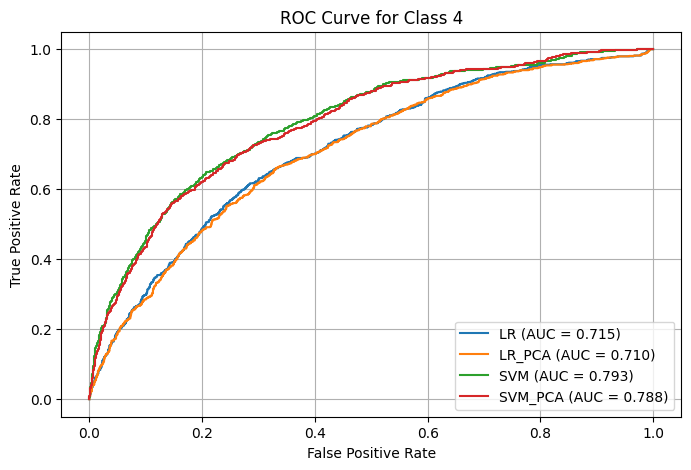

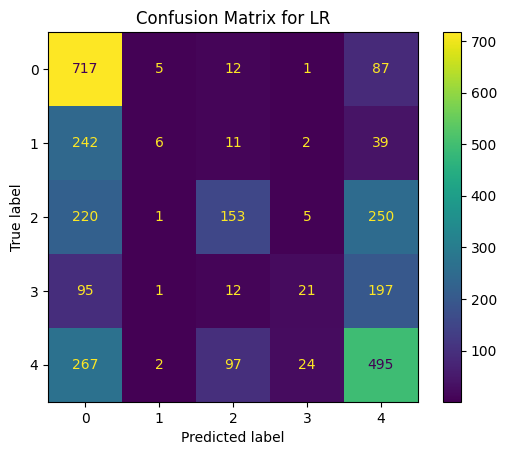

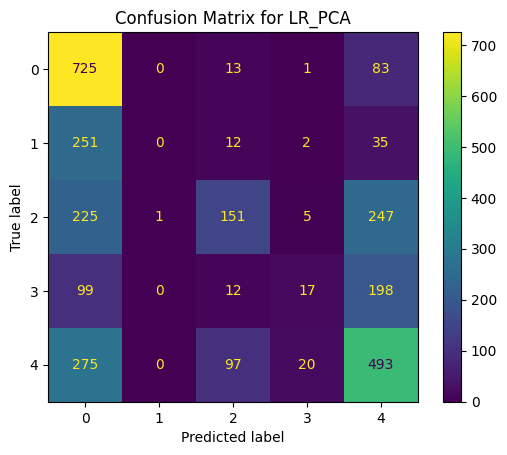

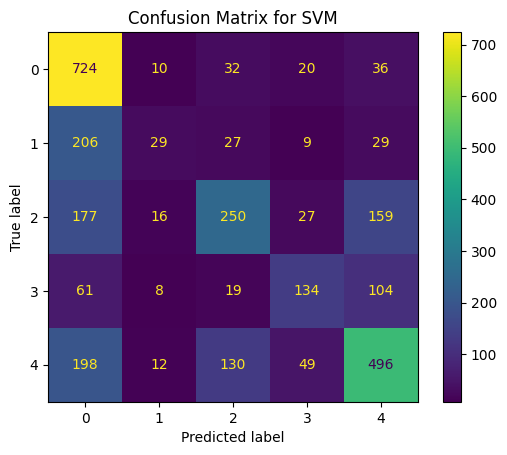

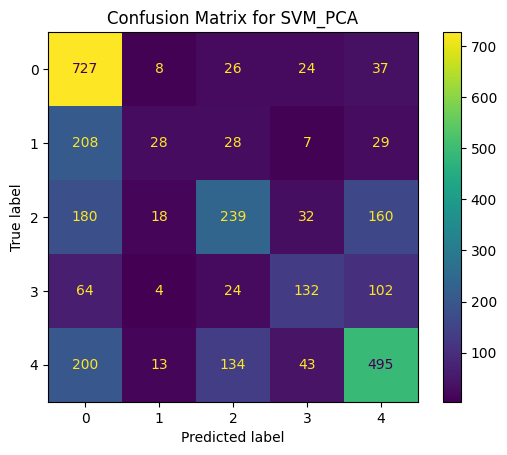

In [ ]:
#add code for evaluation
#______________________________________________________________START_Dananjaya____________________________________________________________

from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

models = {
    "LR" : log_reg_best,
    "LR_PCA" : log_reg_best_pca,
    "SVM" : svm_best,
    "SVM_PCA" : svm_best_pca
}

results = {}

for name, model in models.items():
    if "PCA" in name:
        X_use = X_test_pca
    else:
        X_use = X_test_scaled

    #preds = model.predict(X_test_scaled if "PCA" not in name else X_test_pca)
    #probs = model.predict_proba(X_test_scaled if "PCA" not in name else X_test_pca)

    ##Predinctions and probability
    preds = model.predict(X_use)
    probs = model.predict_proba(X_use)

    #metrics
    bal_acc = balanced_accuracy_score(y_test, preds)
    macro_auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro")
    micro_auc = roc_auc_score(y_test, probs, multi_class="ovr", average="micro")

    results[name] = {
        "Balanced Accuracy" : bal_acc,
        "Macro AUC" : macro_auc,
        "Micro AUC" : micro_auc
    }
print(results)




#ROC curcves (MACRO, MICRO & PRE CLASS)
#One vs rest Binarized Targets

classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]


# Macro-average ROC Curves for all methods (Plot all on one figure)
plt.figure(figsize=(10, 6))
for name, model in models.items():
  if "PCA" in name:
    X_use = X_test_pca
  else:
    X_use = X_test_scaled

  probs = model.predict_proba(X_use)
  fpr = dict()
  tpr = dict()

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])

  # Compute macro-average for the current model
  all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
  mean_tpr = np.zeros_like(all_fpr)

  for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

  mean_tpr /= n_classes
  macro_auc_model = auc(all_fpr, mean_tpr)

  plt.plot(all_fpr, mean_tpr, label = f"{name} (Macro AUC = {macro_auc_model:.3f})")

plt.title("Macro-average ROC Curve (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()


# Micro-average ROC curves for all methods (Plot all on one figure)
plt.figure(figsize=(10, 6))
for name, model in models.items():
  if "PCA" in name:
    X_use = X_test_pca
  else:
    X_use = X_test_scaled

  probs = model.predict_proba(X_use)

  fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
  micro_auc_model = auc(fpr, tpr)

  plt.plot(fpr, tpr, label = f"{name} (Micro AUC = {micro_auc_model:.3f})")

plt.title("Micro-average ROC Curve (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()


# Per-class ROC curves (One vs rest) - one plot per class, all models on it
for i in range(n_classes):
  plt.figure(figsize=(8, 5)) # New figure for each class
  for name, model in models.items():

    if "PCA" in name:
      X_use = X_test_pca
    else:
      X_use = X_test_scaled

    probs = model.predict_proba(X_use)

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc_class = auc(fpr, tpr)

    plt.plot(fpr, tpr, label = f"{name} (AUC = {roc_auc_class:.3f})")

  plt.title(f"ROC Curve for Class {classes[i]}")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()


# Confusion matrices (one per model)
for name, model in models.items():
  if "PCA" in name:
    X_use = X_test_pca
  else:
    X_use = X_test_scaled

  preds = model.predict(X_use)

  ConfusionMatrixDisplay.from_predictions(y_test, preds)
  plt.title(f"Confusion Matrix for {name}")
  plt.grid(False)
  plt.show()

  #_________________________________________________END_DANANJAYA_________________________________________


4. Model Evaluation

Classification Results

Random Forest:
------------------------------
Balanced Accuracy: 0.5939
ROC AUC (Macro-average): 0.8941
ROC AUC (Micro-average): 0.9032
Confusion Matrix:
[[724   6  19  15  58]
 [105 117  28   9  41]
 [114   9 309  19 178]
 [ 34   3  24 138 127]
 [ 88   3  80  20 694]]

K-Nearest Neighbors:
------------------------------
Balanced Accuracy: 0.6148
ROC AUC (Macro-average): 0.8469
ROC AUC (Micro-average): 0.8610
Confusion Matrix:
[[673  39  45  15  50]
 [ 81 168  21  11  19]
 [125  29 326  25 124]
 [ 59  10  24 162  71]
 [ 87  30 112  54 602]]

Random Forest (PCA):
------------------------------
Balanced Accuracy: 0.4990
ROC AUC (Macro-average): 0.8517
ROC AUC (Micro-average): 0.8676
Confusion Matrix:
[[688  10  34  14  76]
 [131  69  50   9  41]
 [138   9 262  15 205]
 [ 44   3  18  91 170]
 [124   5  84  24 648]]

KNN (PCA):
------------------------------
Balanced Accuracy: 0.5307
ROC AUC (Macro-average): 0.8271
ROC AUC (Micro-average): 0.84

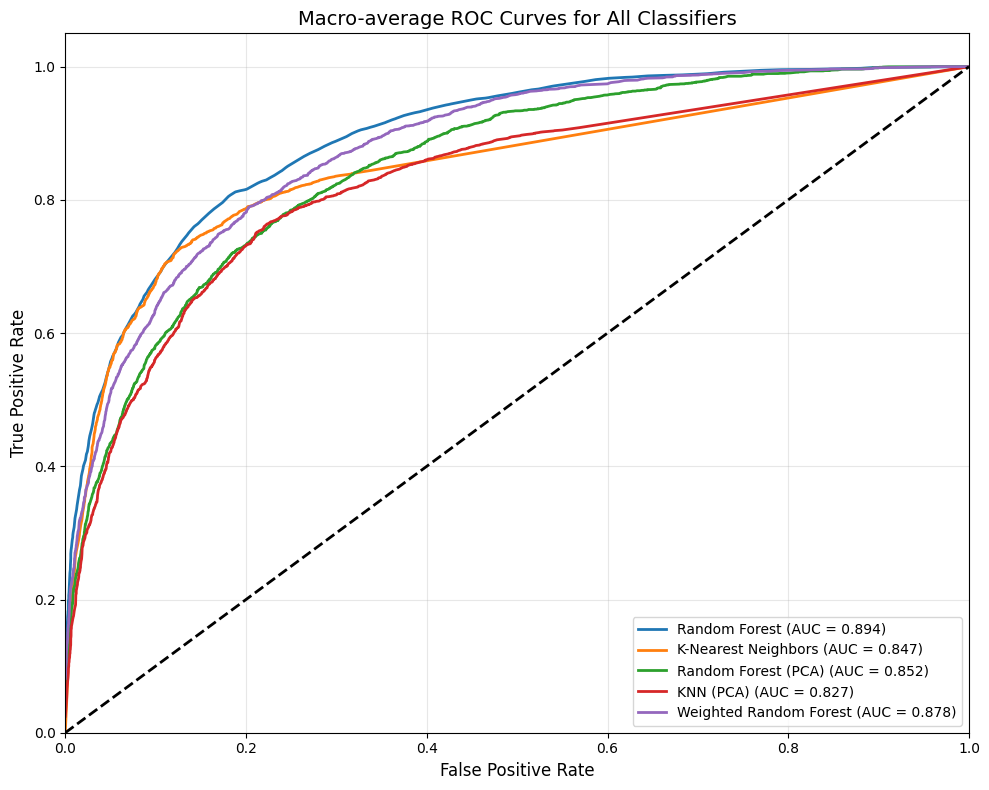

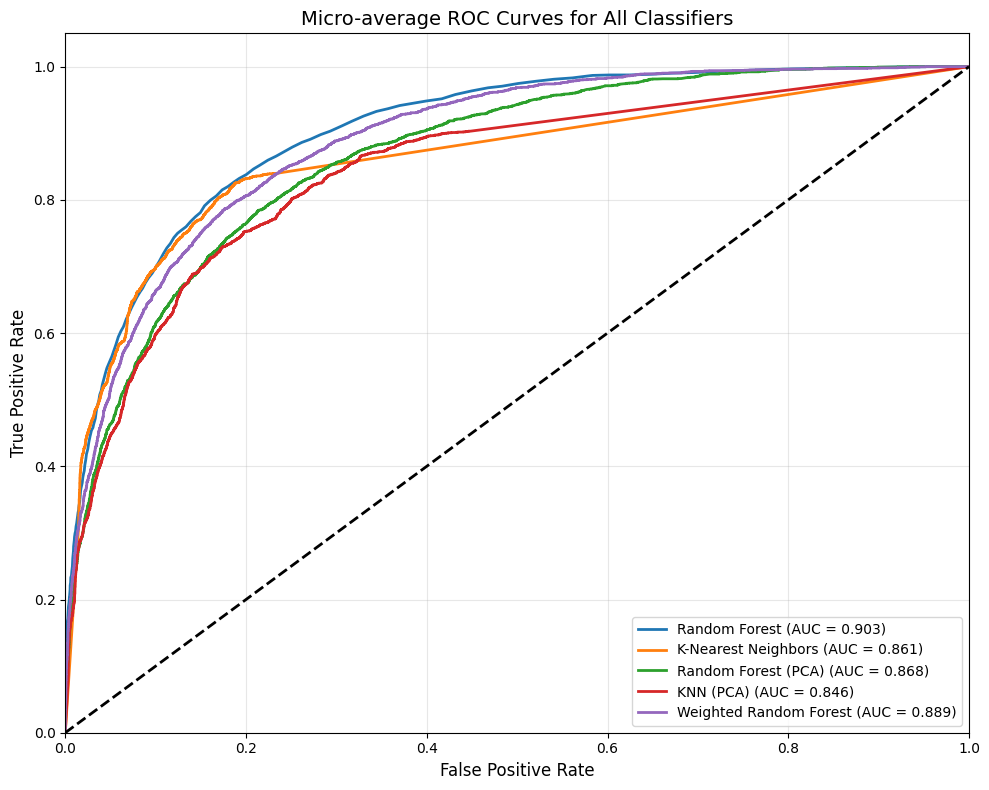


5.1 Per-Class ROC Curves (All Methods Combined)


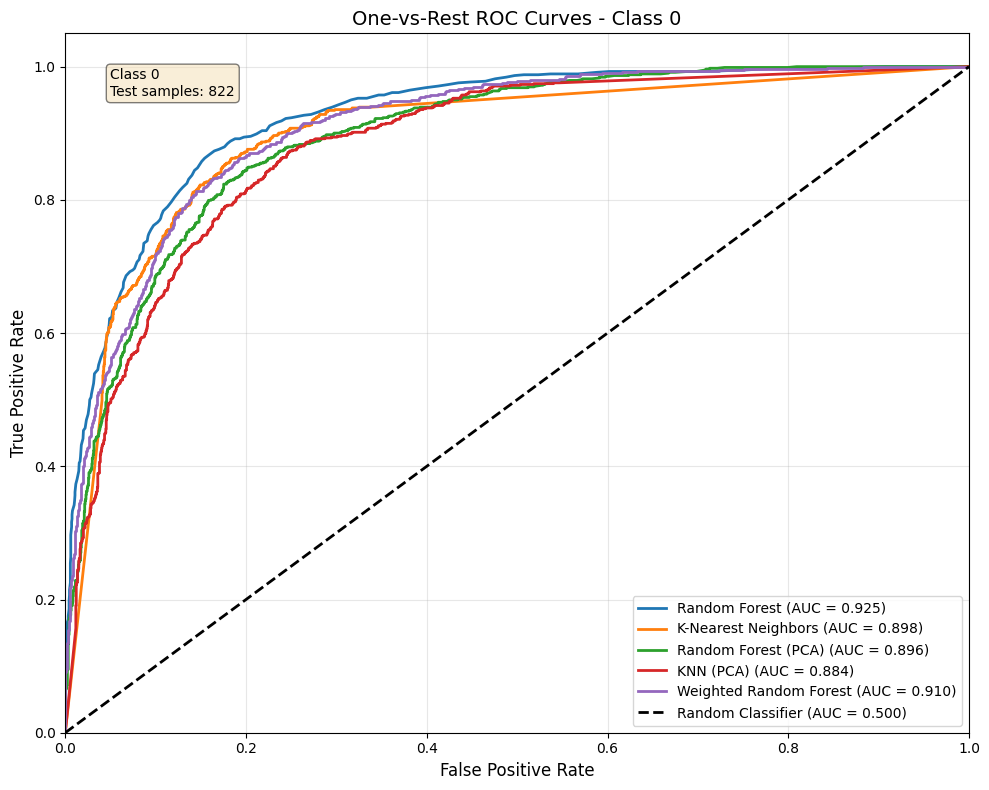

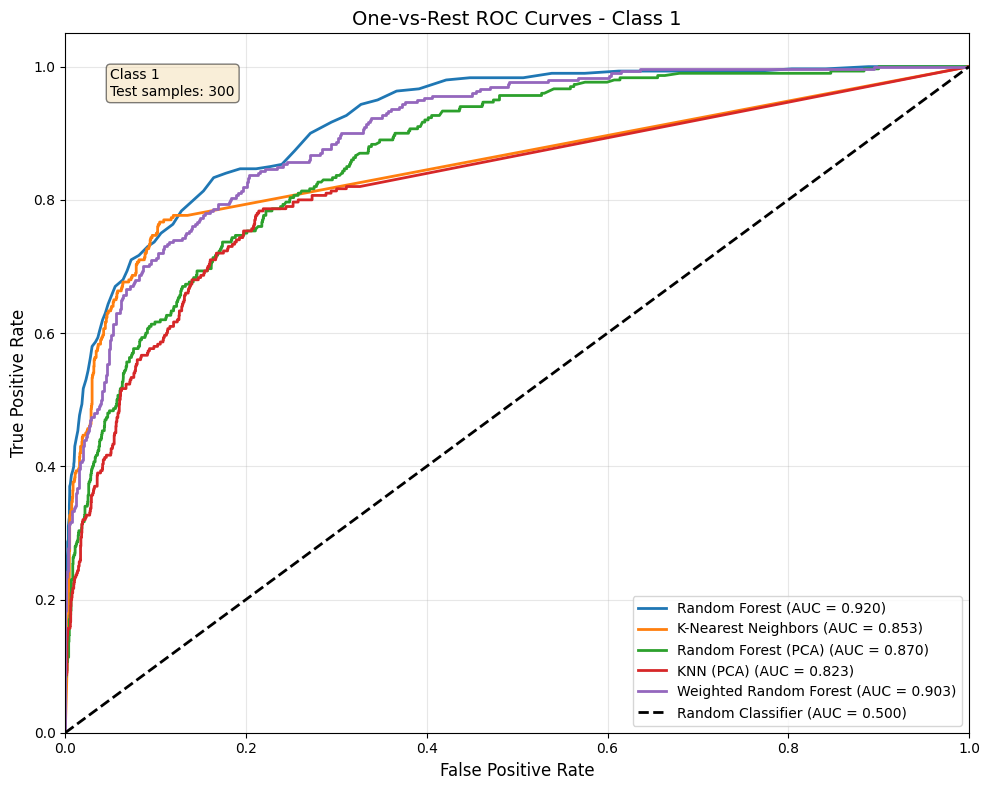

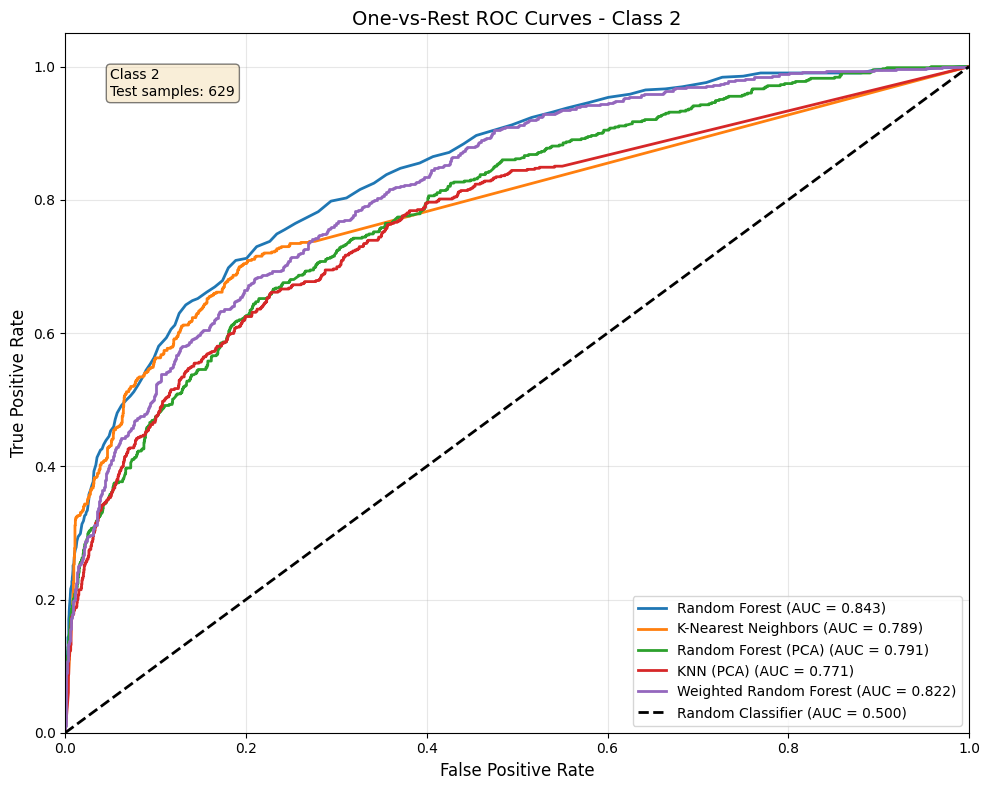

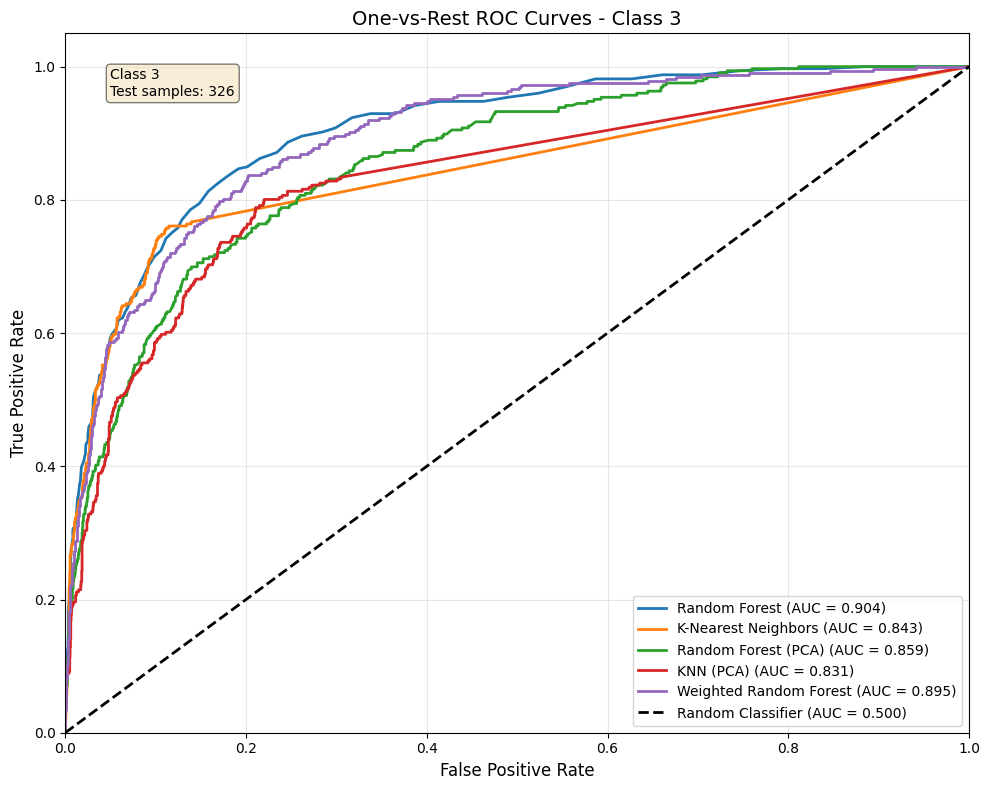

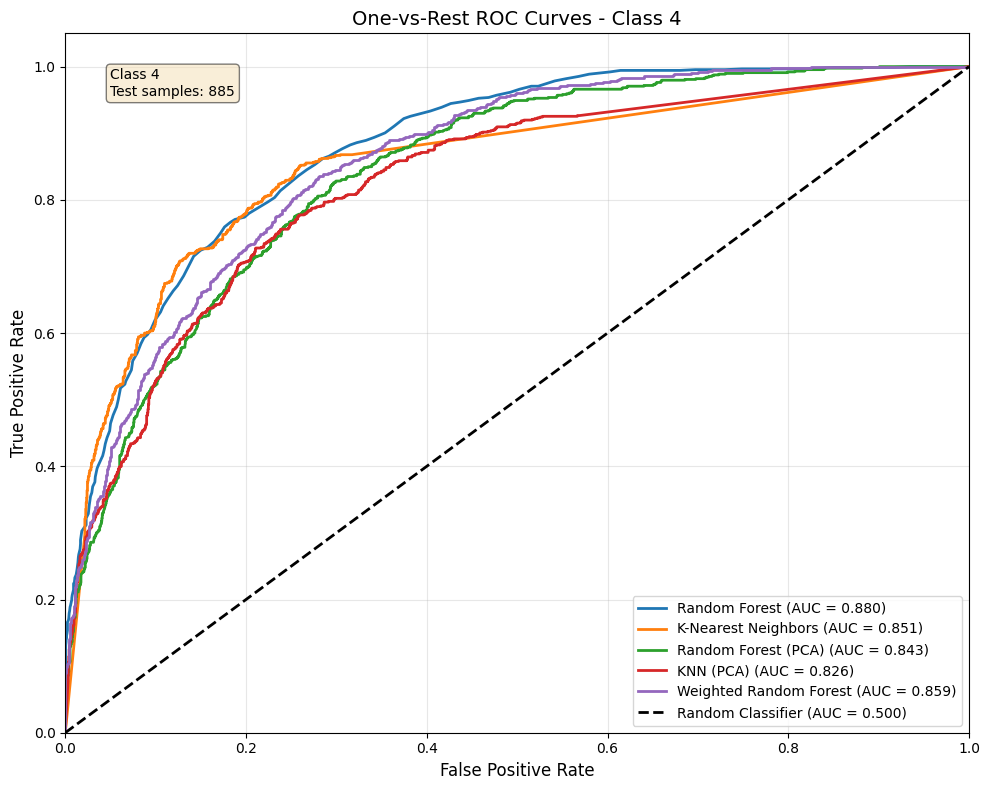


5.3 ROC AUC Summary by Class

ROC AUC Scores by Class and Method:
 Class  Random Forest  K-Nearest Neighbors  Random Forest (PCA)  KNN (PCA)  Weighted Random Forest
     0         0.9248               0.8982               0.8962     0.8839                  0.9100
     1         0.9195               0.8529               0.8695     0.8233                  0.9027
     2         0.8428               0.7890               0.7906     0.7713                  0.8219
     3         0.9039               0.8430               0.8587     0.8310                  0.8946
     4         0.8795               0.8514               0.8434     0.8258                  0.8591

6. Confusion Matrices


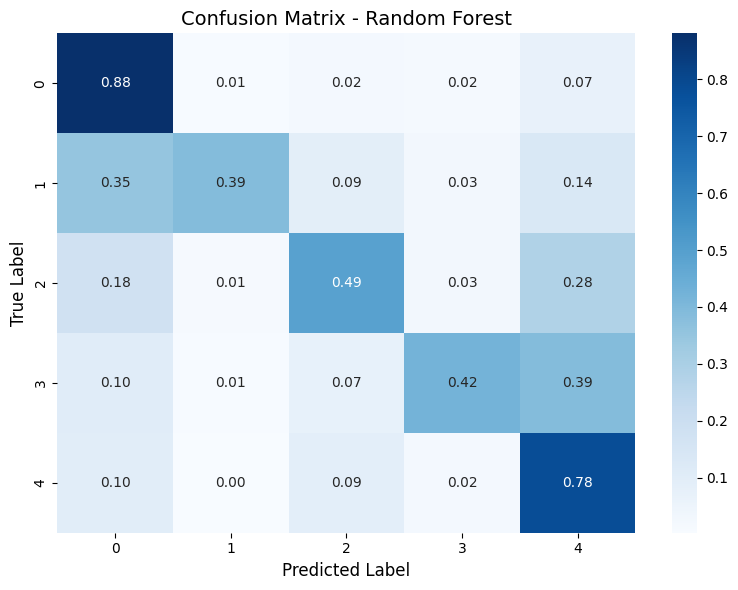

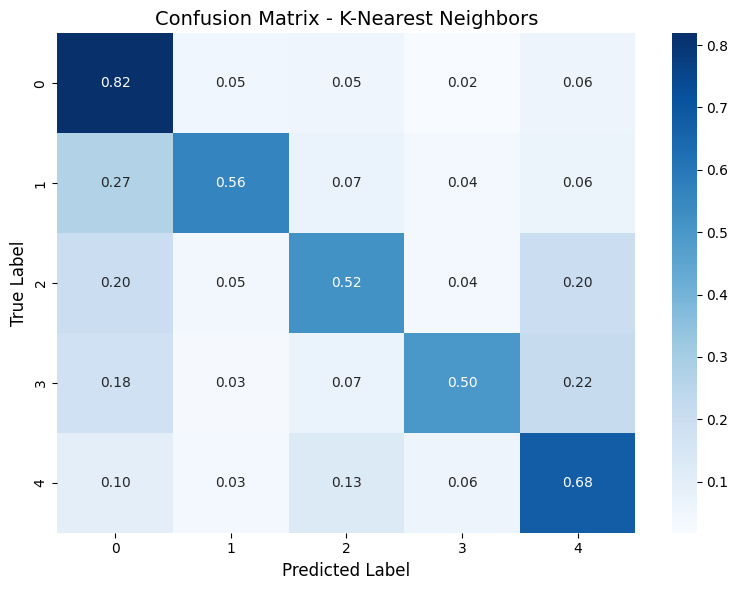

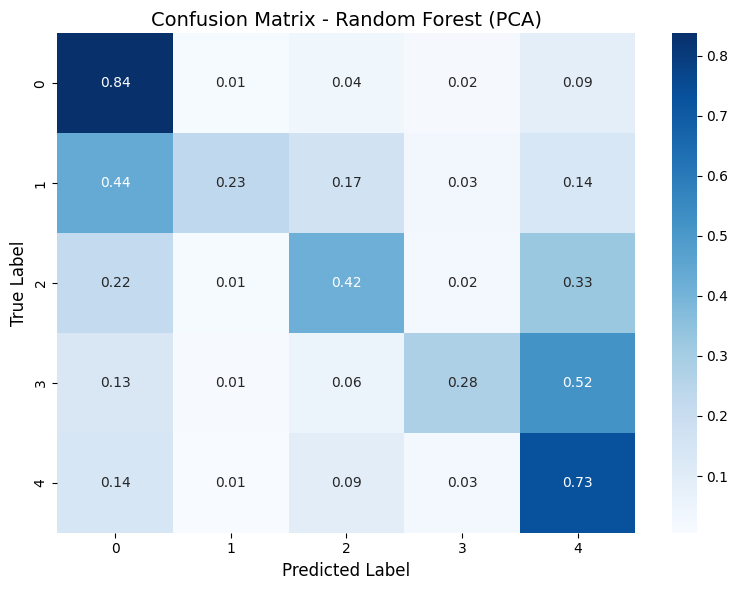

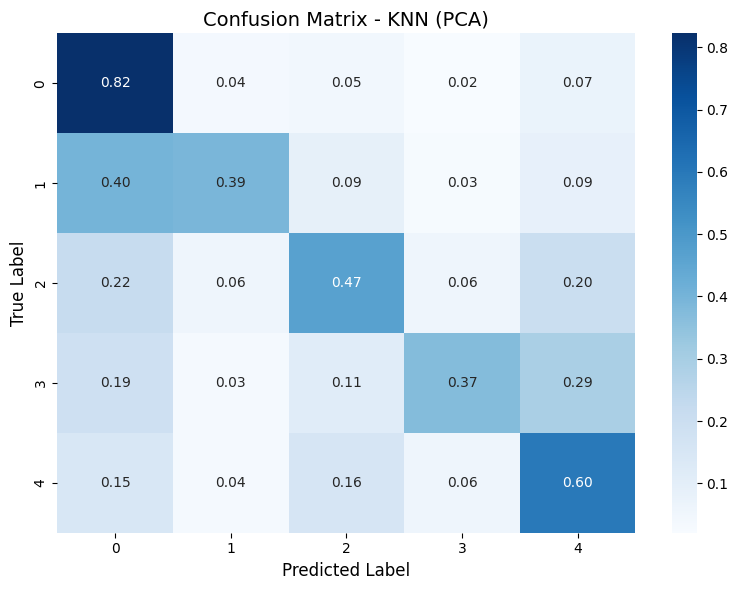

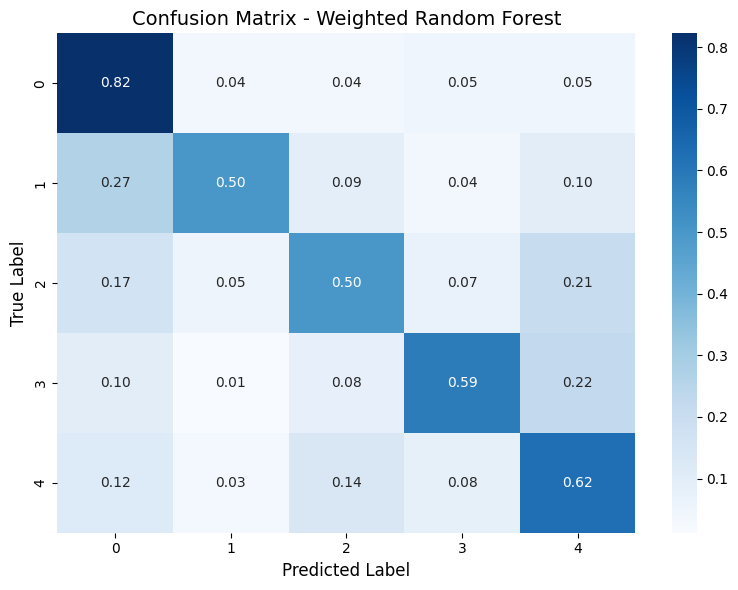


7. Performance Summary Table

Overall Performance Comparison:
                Method Balanced Accuracy ROC AUC (Macro) ROC AUC (Micro)
         Random Forest            0.5939          0.8941          0.9032
   K-Nearest Neighbors            0.6148          0.8469          0.8610
   Random Forest (PCA)            0.4990          0.8517          0.8676
             KNN (PCA)            0.5307          0.8271          0.8458
Weighted Random Forest            0.6066          0.8777          0.8895

Best Method per Class (Based on ROC AUC)
Class 0: Random Forest (AUC = 0.9248)
Class 1: Random Forest (AUC = 0.9195)
Class 2: Random Forest (AUC = 0.8428)
Class 3: Random Forest (AUC = 0.9039)
Class 4: Random Forest (AUC = 0.8795)


In [ ]:
#___________________________________________START_NETHRA____________________________________________________________
# 4. Model Evaluation
# ============================================
print("\n" + "="*50)
print("4. Model Evaluation")
print("="*50)

# List all models
models = {
    'Random Forest': best_rf,
    'K-Nearest Neighbors': best_knn,
    'Random Forest (PCA)': rf_pca,
    'KNN (PCA)': knn_pca,
    'Weighted Random Forest': best_rf_weighted
}

# Test data
X_test_scaled = scaler.transform(X_test_raw)

# For models trained on PCA, use PCA-transformed test data
test_data = {
    'Random Forest': X_test_scaled,
    'K-Nearest Neighbors': X_test_scaled,
    'Random Forest (PCA)': X_test_pca,
    'KNN (PCA)': X_test_pca,
    'Weighted Random Forest': X_test_scaled
}

# Store results
results = {}

print("\n" + "="*50)
print("Classification Results")
print("="*50)

for name, model in models.items():
    print(f"\n{name}:")
    print("-"*30)

    # Predictions
    y_pred = model.predict(test_data[name])
    y_proba = model.predict_proba(test_data[name])

    # Calculate balanced accuracy
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    # Calculate ROC AUC (macro and micro average)
    # Convert y_test to numeric labels for ROC calculation
    from sklearn.preprocessing import label_binarize
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Calculate macro and micro ROC AUC
    roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
    roc_auc_micro = roc_auc_score(y_test_bin, y_proba, average='micro', multi_class='ovr')

    # Store results
    results[name] = {
        'Balanced Accuracy': bal_acc,
        'ROC AUC (Macro)': roc_auc_macro,
        'ROC AUC (Micro)': roc_auc_micro,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'model': model
    }

    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"ROC AUC (Macro-average): {roc_auc_macro:.4f}")
    print(f"ROC AUC (Micro-average): {roc_auc_micro:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix:\n{cm}")
# 5. Visualization: ROC Curves
# ============================================
print("\n" + "="*50)
print("5. ROC Curve Visualization")
print("="*50)

# Get unique classes
classes = np.unique(y_test)
n_classes = len(classes)

# Figure 1: Macro-average ROC curves
plt.figure(figsize=(10, 8))

for name, result in results.items():
    y_proba = result['y_proba']
    y_test_bin = label_binarize(y_test, classes=classes)

    # Compute macro-average ROC curve
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = roc_auc_score(y_test_bin[:, i], y_proba[:, i])

    # Compute macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = np.mean(list(roc_auc.values()))

    plt.plot(fpr["macro"], tpr["macro"], lw=2,
             label=f'{name} (AUC = {roc_auc["macro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Macro-average ROC Curves for All Classifiers', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('macro_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Micro-average ROC curves
plt.figure(figsize=(10, 8))

for name, result in results.items():
    y_proba = result['y_proba']
    y_test_bin = label_binarize(y_test, classes=classes)

    # Compute micro-average ROC curve
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    roc_auc = roc_auc_score(y_test_bin, y_proba, average='micro', multi_class='ovr')

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Micro-average ROC Curves for All Classifiers', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('micro_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 3: Per-class ROC curves - Separate graph for each class
# This shows all classifiers on the same graph for each class
print("\n" + "="*50)
print("5.1 Per-Class ROC Curves (All Methods Combined)")
print("="*50)

# Create a separate figure for each class
for i in range(n_classes):
    plt.figure(figsize=(10, 8))

    # Plot ROC curve for each classifier for this specific class
    for name, result in results.items():
        y_proba = result['y_proba']
        y_test_bin = label_binarize(y_test, classes=classes)

        # Get ROC curve for this class
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])

        # Plot with different colors and markers for each method
        plt.plot(fpr, tpr, lw=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

    # Add diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

    # Customize the plot
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'One-vs-Rest ROC Curves - Class {classes[i]}', fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)

    # Add text box with class information
    class_count = np.sum(y_test == classes[i])
    textstr = f'Class {classes[i]}\nTest samples: {class_count}'
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

    plt.tight_layout()
    plt.savefig(f'per_class_roc_class_{classes[i]}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 5.3 ROC Analysis Summary Table
# ============================================
print("\n" + "="*50)
print("5.3 ROC AUC Summary by Class")
print("="*50)

# Create a summary table of AUC scores for each class and method
roc_summary = pd.DataFrame()
roc_summary['Class'] = classes

for name, result in results.items():
    y_proba = result['y_proba']
    y_test_bin = label_binarize(y_test, classes=classes)

    class_auc = []
    for i in range(n_classes):
        auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        class_auc.append(auc)

    roc_summary[name] = class_auc

print("\nROC AUC Scores by Class and Method:")
print("="*50)
print(roc_summary.round(4).to_string(index=False))

# ============================================
# 6. Confusion Matrix Visualization
# ============================================
print("\n" + "="*50)
print("6. Confusion Matrices")
print("="*50)

for name, result in results.items():
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, result['y_pred'])

    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix - {name}', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 7. Performance Summary Table
# ============================================
print("\n" + "="*50)
print("7. Performance Summary Table")
print("="*50)

# Create comprehensive summary dataframe
summary_data = []
for name, result in results.items():
    summary_data.append({
        'Method': name,
        'Balanced Accuracy': f"{result['Balanced Accuracy']:.4f}",
        'ROC AUC (Macro)': f"{result['ROC AUC (Macro)']:.4f}",
        'ROC AUC (Micro)': f"{result['ROC AUC (Micro)']:.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nOverall Performance Comparison:")
print(summary_df.to_string(index=False))

# Calculate and display best performing method for each class
print("\n" + "="*50)
print("Best Method per Class (Based on ROC AUC)")
print("="*50)

for i, class_label in enumerate(classes):
    class_results = []
    for name, result in results.items():
        y_proba = result['y_proba']
        y_test_bin = label_binarize(y_test, classes=classes)
        auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        class_results.append((name, auc))

    best_method = max(class_results, key=lambda x: x[1])
    print(f"Class {class_label}: {best_method[0]} (AUC = {best_method[1]:.4f})")


#______________________________________________________________END_NETHRA____________________________________________________________


            BALANCED ACCURACY SCORES
Decision Tree       : 0.4757
Decision Tree (PCA) : 0.4128
AdaBoost            : 0.3741
AdaBoost (PCA)      : 0.3665
Gaussian NB         : 0.3426
Gaussian NB (PCA)   : 0.3254
MLP                 : 0.5180
MLP (PCA)           : 0.5159


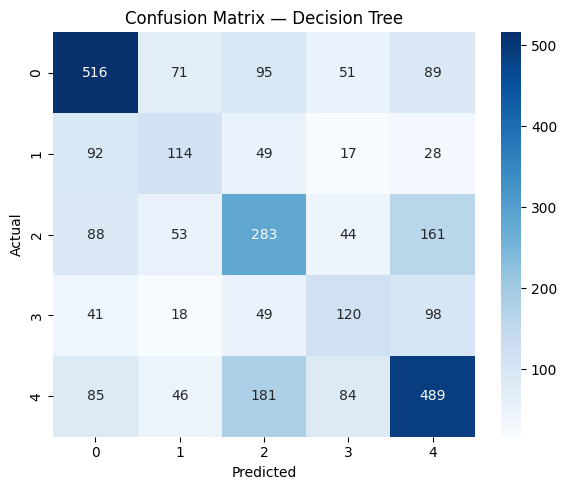

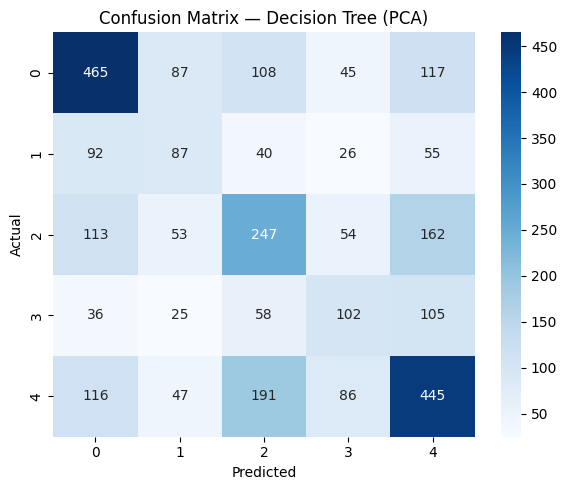

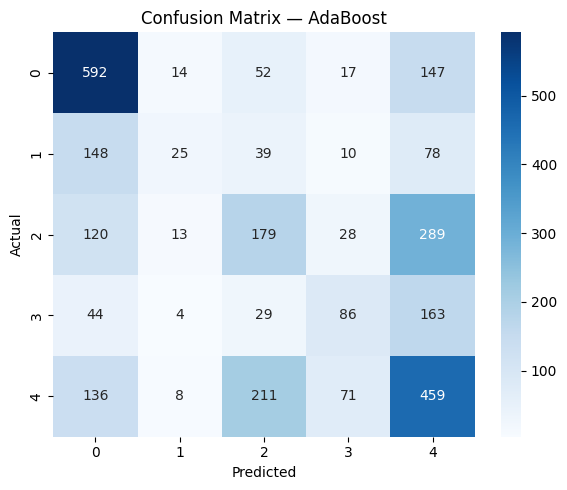

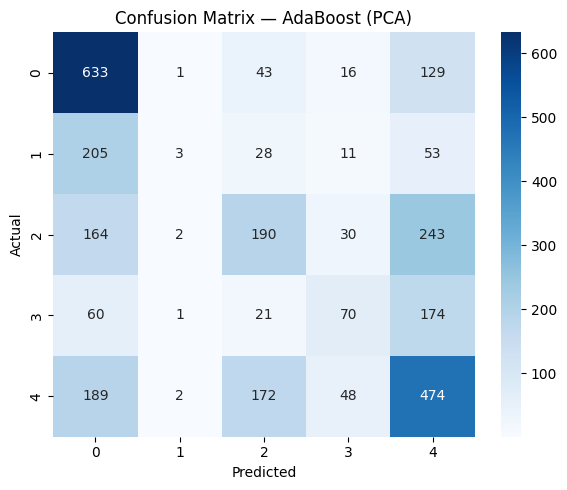

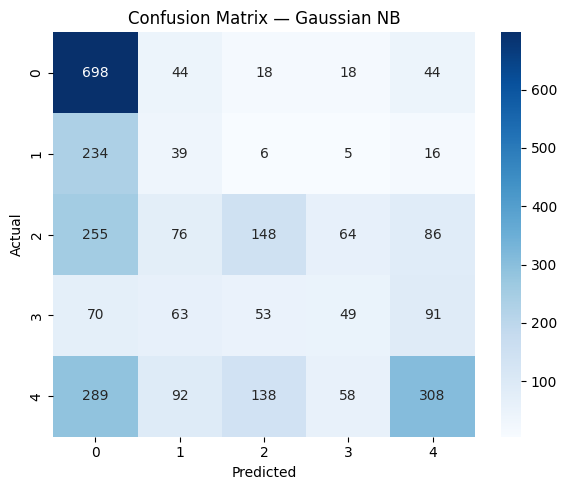

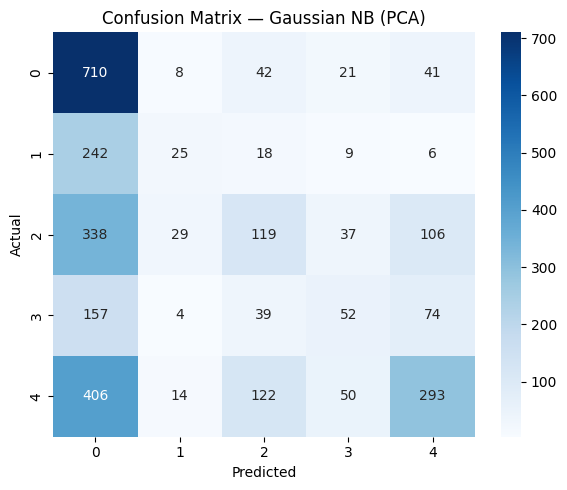

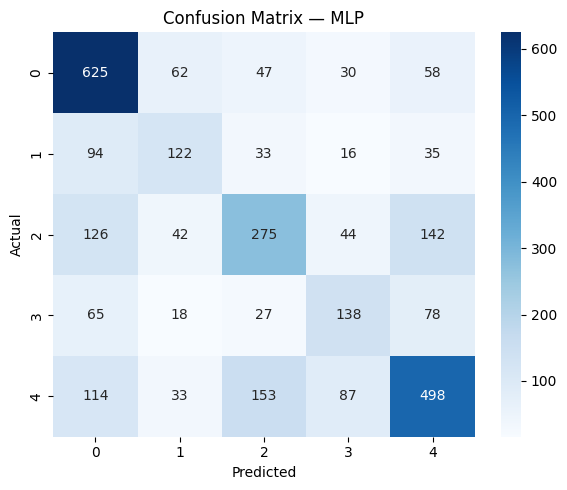

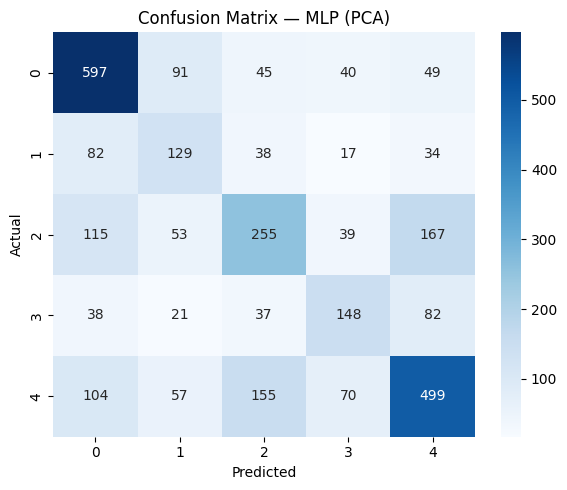

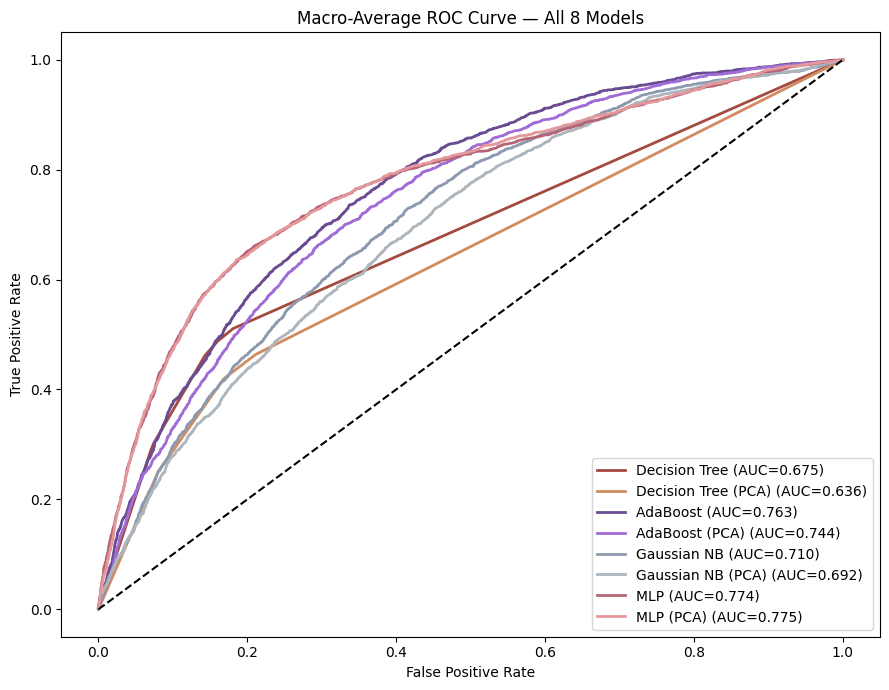

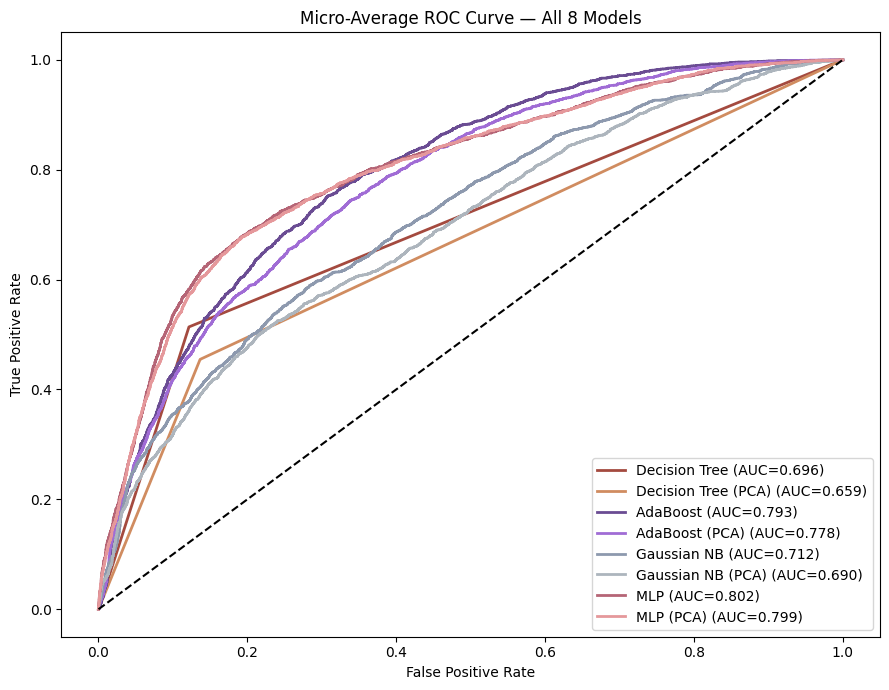

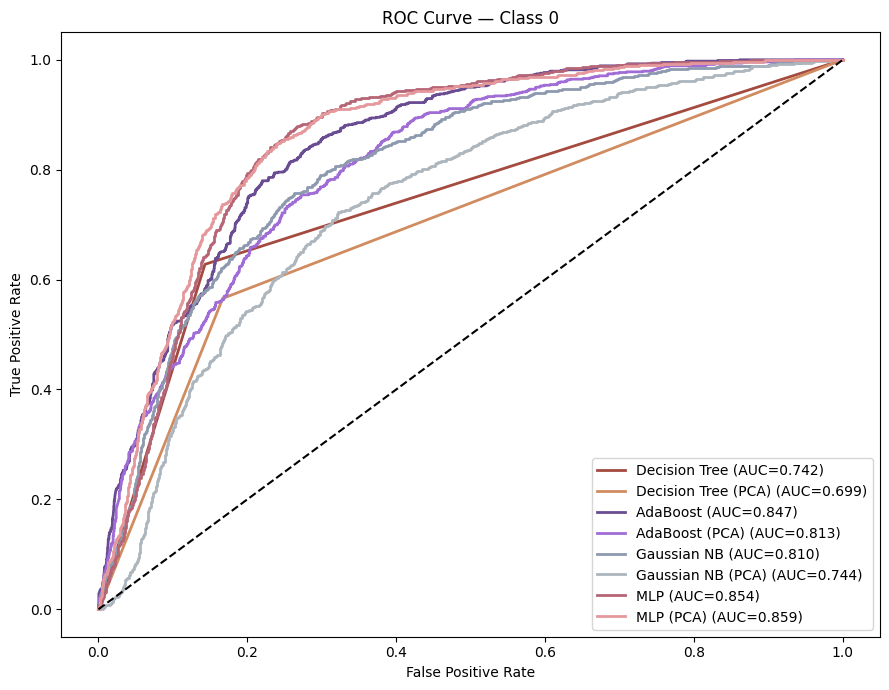

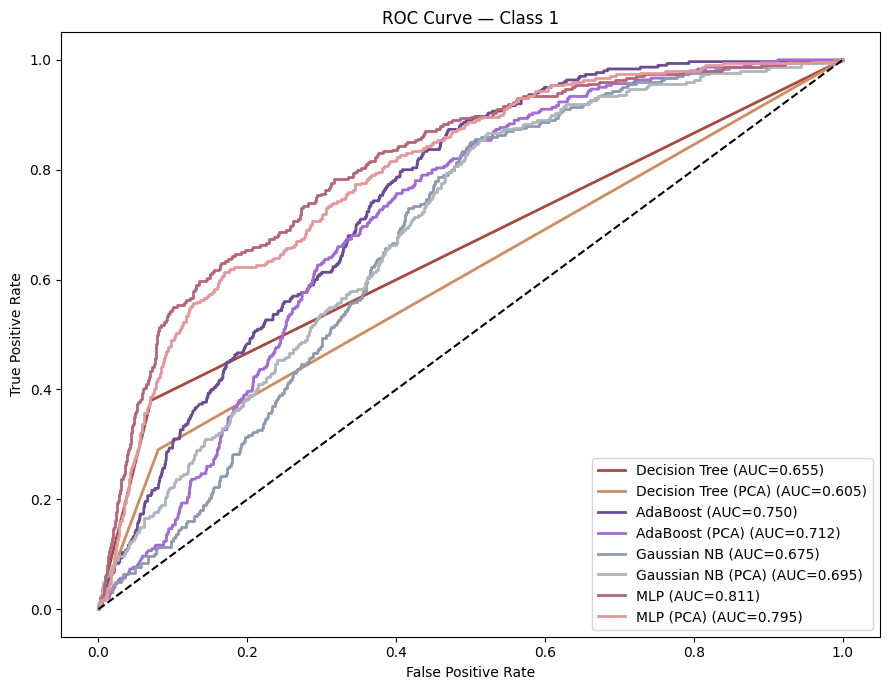

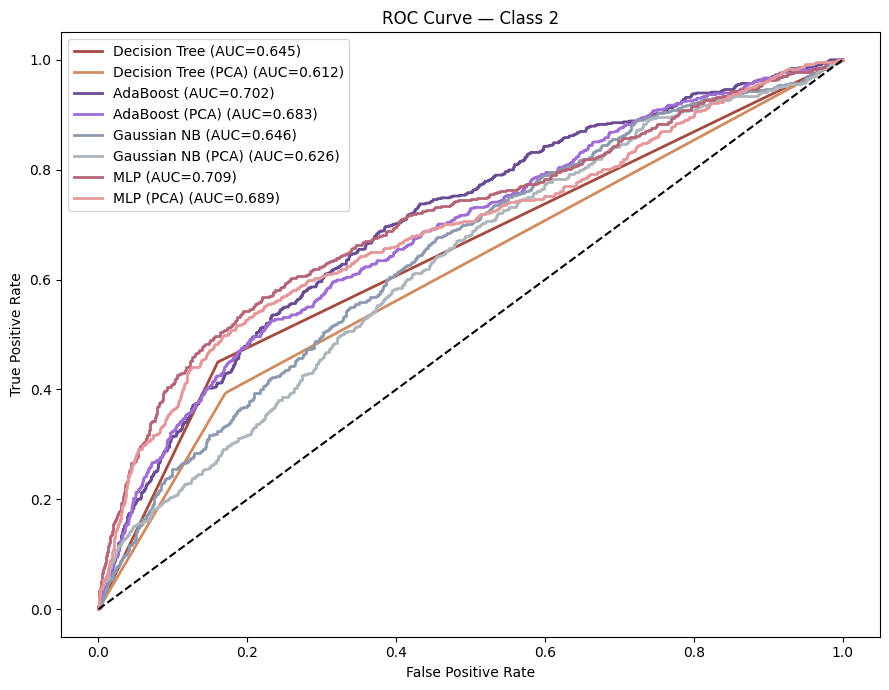

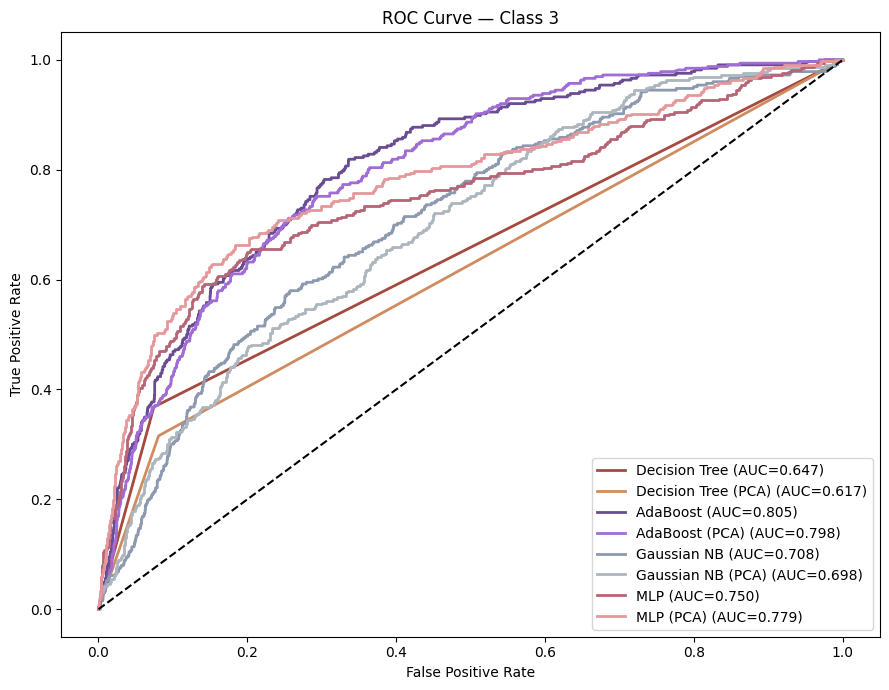

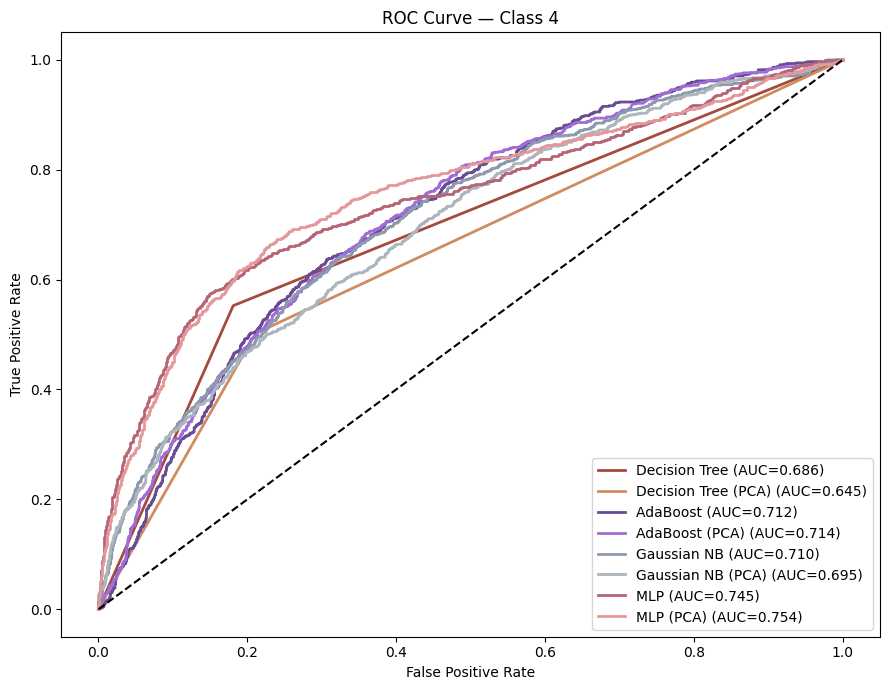


                   CLASSIFICATION REPORTS


--- Decision Tree ---
Balanced Accuracy: 0.4757

              precision    recall  f1-score   support

           0     0.6277    0.6277    0.6277       822
           1     0.3775    0.3800    0.3787       300
           2     0.4307    0.4499    0.4401       629
           3     0.3797    0.3681    0.3738       326
           4     0.5653    0.5525    0.5589       885

    accuracy                         0.5138      2962
   macro avg     0.4762    0.4757    0.4759      2962
weighted avg     0.5146    0.5138    0.5142      2962


--- Decision Tree (PCA) ---
Balanced Accuracy: 0.4128

              precision    recall  f1-score   support

           0     0.5657    0.5657    0.5657       822
           1     0.2910    0.2900    0.2905       300
           2     0.3835    0.3927    0.3881       629
           3     0.3259    0.3129    0.3192       326
           4     0.5034    0.5028    0.5031       885

    accuracy                       

In [ ]:
#K2635944 - Sadeep
#Evaluation - Decision Tree, AdaBoost, Gaussian NB, MLP

#Model dictionary
tuned_models = {
    "Decision Tree": dt_best,
    "Decision Tree (PCA)": dt_best_pca,
    "AdaBoost": ada_best,
    "AdaBoost (PCA)": ada_best_pca,
    "Gaussian NB": nb_best,
    "Gaussian NB (PCA)": nb_best_pca,
    "MLP": mlp_best,
    "MLP (PCA)": mlp_best_pca
}

#Generate predictions, probabilities, balanced accuracy
from sklearn.metrics import balanced_accuracy_score

preds = {}
probs = {}
scores = {}

print("===================================================")
print("            BALANCED ACCURACY SCORES")
print("===================================================")

for name, model in tuned_models.items():

    # Select correct test matrix
    if "PCA" in name:
        X_eval = X_test_pca
    elif "MLP" in name:
        X_eval = X_test_scaled
    else:
        X_eval = X_test_scaled # Changed from X_test to X_test_scaled

    preds[name] = model.predict(X_eval)
    probs[name] = model.predict_proba(X_eval)
    scores[name] = balanced_accuracy_score(y_test, preds[name])

    print(f"{name:20s}: {scores[name]:.4f}")

#Confusion Matrices
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

classes = np.unique(y_test)

for name in tuned_models.keys():
    cm = confusion_matrix(y_test, preds[name], labels=classes)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"cm_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png", dpi=300)
    plt.show()

#Colour palette for ROC curves
colors = {
    "Decision Tree": "#a44a3f",
    "Decision Tree (PCA)": "#d08c60",
    "AdaBoost": "#6a4c93",
    "AdaBoost (PCA)": "#a06cd5",
    "Gaussian NB": "#8d99ae",
    "Gaussian NB (PCA)": "#adb5bd",
    "MLP": "#b56576",
    "MLP (PCA)": "#e5989b"
}

#One‑vs‑Rest labels
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = len(classes) # Define n_classes here

#Macro‑Average ROC Curve
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9,7))

for name in tuned_models.keys():

    fpr = {}
    tpr = {}

    # Compute ROC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[name][:, i])

    # Macro average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    auc_macro = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr,
             label=f"{name} (AUC={auc_macro:.3f})",
             linewidth=2,
             color=colors[name])

plt.plot([0,1],[0,1],"k--")
plt.title("Macro-Average ROC Curve — All 8 Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_macro_8models.png", dpi=300)
plt.show()

#Micro‑Average ROC Curve
plt.figure(figsize=(9,7))

for name in tuned_models.keys():

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        probs[name].ravel()
    )
    auc_micro = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{name} (AUC={auc_micro:.3f})",
             linewidth=2,
             color=colors[name])

plt.plot([0,1],[0,1],"k--")
plt.title("Micro-Average ROC Curve — All 8 Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("roc_micro_8models.png", dpi=300)
plt.show()

#Per-class ROC Curves
for i, cls in enumerate(classes):
    plt.figure(figsize=(9,7))

    for name in tuned_models.keys():
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[name][:, i])
        auc_val = auc(fpr, tpr)

        plt.plot(fpr, tpr,
                 label=f"{name} (AUC={auc_val:.3f})",
                 linewidth=2,
                 color=colors[name])

    plt.plot([0,1], [0,1], "k--")
    plt.title(f"ROC Curve — Class {cls}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"roc_class_{cls}_8models.png", dpi=300)
    plt.show()

#Classification Report Summary
from sklearn.metrics import classification_report

print("\n===================================================")
print("                   CLASSIFICATION REPORTS")
print("===================================================\n")

for name in tuned_models.keys():

    # Correct test data
    if "PCA" in name:
        X_eval = X_test_pca
    elif "MLP" in name:
        X_eval = X_test_scaled
    else:
        X_eval = X_test_scaled # Changed from X_test to X_test_scaled

    print(f"\n--- {name} ---")
    print(f"Balanced Accuracy: {scores[name]:.4f}\n")

    print(classification_report(
        y_test,
        preds[name],
        digits=4
    ))
#end

# References

List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).
-Dananjaya
* Pedregosa et al., "Scikit-learn: Machine Learning in Python," JMLR, 2011.
* Bishop, C. "Pattern Recognition and Machine Learning," Springer, 2006.
* Hastie, Tibshirani & Friedman, "The Elements of Statistical Learning," Springer, 2009.
* OpenML Dataset 4538: GesturePhaseSegmentationProcessed.

-Nethra
* Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.

* Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification.
   IEEE Transactions on Information Theory, 13(1), 21-27.

* Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python.
   Journal of Machine Learning Research, 12, 2825-2830.

* Varoquaux, G., et al. (2015). Scikit-learn: Machine Learning Without
   Learning the Machinery. GetMobile: Mobile Computing and Communications, 19(1), 29-33.

Sadeep

[1] M. Feurer, J. N. Van Rijn, A. Kadra, P. Gijsbers, N. Mallik, S. Ravi, A. Müller, J. Vanschoren, and F. Hutter, “OpenML‑Python: An extensible Python API for OpenML,” Journal of Machine Learning Research, vol. 22, no. 100, pp. 1–5, 2021.

[2] OpenML, “GesturePhaseSegmentationProcessed (Data ID: 4538),” 2016. [Online]. Available: https://www.openml.org/d/4538

[3] L. Buitinck, G. Louppe, M. Blondel, F. Pedregosa, A. Mueller, O. Grisel, V. Niculae, P. Prettenhofer, R. Weiss, and J. Vanderplas, “API design for machine learning software: Experiences from the scikit-learn project,” in ECML PKDD Workshop: Languages for Data Mining and Machine Learning, 2013.

[4] F. Pedregosa et al., “Scikit‑learn: Machine learning in Python,” Journal of Machine Learning Research, vol. 12, pp. 2825–2830, 2011.

[5] Scikit‑learn Developers, “fetch_openml — scikit‑learn documentation,” 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html

[6] Scikit‑learn Developers, “GridSearchCV — scikit‑learn documentation,” 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

[7] Scikit‑learn Developers, “ROC and AUC metrics — scikit‑learn documentation,” 2024. [Online]. Available: https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics

[8] Scikit‑learn Developers, “Confusion Matrix — scikit‑learn documentation,” 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

[9] Scikit‑learn Developers, “PCA: Principal Component Analysis — scikit‑learn documentation,” 2024. [Online]. Available: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

[10] T. Hastie, R. Tibshirani, and J. Friedman, The Elements of Statistical Learning, 2nd ed. Springer, 2009.

[11] I. Goodfellow, Y. Bengio, and A. Courville, Deep Learning. MIT Press, 2016.

[12] K. P. Murphy, Machine Learning: A Probabilistic Perspective. MIT Press, 2012.   